In [25]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [13]:

dname = "/rd2/MST_ISR_EEJ_cont/processed/mesosphere/fit_gg/spc1min"
rtifile = '/rd2/MST_ISR_EEJ_cont/processed/mesosphere/fit_gg/spc1min/2015/Maps/fitmap_2015.07.06.npz'
uvwfile = '/rd2/MST_ISR_EEJ_cont/processed/mesosphere/fit_gg/spc1min/2015/Maps/windmap2_2015.07.06.npz'
spcfile = '/rd2/MST_ISR_EEJ_cont/processed/MST/spc/y2015/spc1min/2015.07.06/2015.07.06.13.21.21.spc60480ms.npz'
fitfile = '/rd2/MST_ISR_EEJ_cont/processed/mesosphere/fit_gg/spc1min/2015/Maps/fitmap_2015.07.06.npz'

rtifile = '/rd2/MST_ISR_EEJ_cont/processed/mesosphere/fit_gg/spc1min/2007/Maps/fitmap_2007.06.19.npz'

In [56]:
uvw = np.load(uvwfile)
for i in uvw:
    print(i)

pU
pV
pW
snrdB_map
dbscan_labels
hts
old_lsq2
old_lsq1
new_lsq1
new_lsq2
n_map
sigmas2
sigmas1
spWidth
U
W
V
acqUTCtime
dV
dW
vel_arr
dU


In [73]:
rti = np.load('/rd2/MST_ISR_EEJ_cont/processed/mesosphere/fit_gg/spc1min/2017/Maps/fitmap_2017.04.18.npz')
for i in rti:
    print (i)


acqUTCtime
snrdB_map
sigmas2_map
sigmas1_map
chiSq1_map
N_map
lsq1_map
hts
chiSq2_map
vel_arr
choice_map
lsq2_map


In [74]:
timearray = rti['acqUTCtime']

In [75]:
timearray

array([[1492513252],
       [1492513312],
       [1492513373],
       [1492513433],
       [1492513494],
       [1492513554],
       [1492513615],
       [1492513675],
       [1492513736],
       [1492513796],
       [1492513857],
       [1492513917],
       [1492513977],
       [1492514038],
       [1492514098],
       [1492514159],
       [1492514219],
       [1492514280],
       [1492514340],
       [1492514401],
       [1492514461],
       [1492514522],
       [1492514582],
       [1492514643],
       [1492514703],
       [1492514764],
       [1492514824],
       [1492514885],
       [1492514945],
       [1492515006],
       [1492515066],
       [1492515127],
       [1492515187],
       [1492515248],
       [1492515308],
       [1492515369],
       [1492515429],
       [1492515489],
       [1492515550],
       [1492515610],
       [1492515671],
       [1492515731],
       [1492515792],
       [1492515852],
       [1492515913],
       [1492515973],
       [1492516034],
       [14925

[ 59  59  59 169   5  59  60  59  59  59]
[1182267768 1182267827 1182267886 1182267945 1182268114 1182268119
 1182268178 1182268238 1182268297 1182268356]


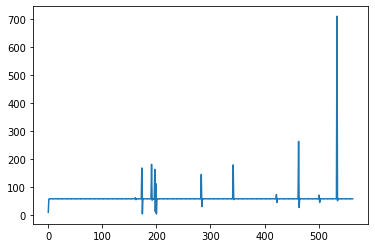

In [34]:
timediff = timearray[1:,0] - timearray[:-1,0]
plt.plot(timediff)
print(timediff[170:180])
print(timearray[170:180,0])

In [61]:
((timediff / np.median(timediff))>1.1).astype(np.int_)
gap_index = ((timediff / np.median(timediff))>1.1).nonzero()[0]
print(gap_index)

[173 191 197 199 283 342 422 463 501 534]


In [71]:
acq_start_index = np.pad(gap_index+1,(1,1),'constant')
acq_start_index[-1] = -1

In [72]:
for (idx_start,idx_end) in zip(acq_start_index[:-1],acq_start_index[1:]):
    print(idx_start,idx_end)

0 174
174 192
192 198
198 200
200 284
284 343
343 423
423 464
464 502
502 535
535 -1


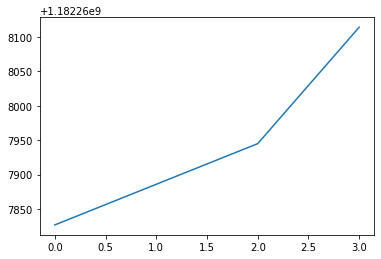

In [55]:
plt.plot(timearray[171:175,0])

In [57]:
rti['snrdB_map'].shape

(565, 4, 201)

In [77]:
time.gmtime(timearray[0,0])

time.struct_time(tm_year=2017, tm_mon=4, tm_mday=18, tm_hour=11, tm_min=0, tm_sec=52, tm_wday=1, tm_yday=108, tm_isdst=0)

In [76]:
time.gmtime(timearray[-1,0])

time.struct_time(tm_year=2017, tm_mon=4, tm_mday=19, tm_hour=0, tm_min=59, tm_sec=36, tm_wday=2, tm_yday=109, tm_isdst=0)